# ***EstateMate*** : AI-Powered Real Estate Valuation DSS

## Artificial Intelligence for Business Decisions nd Transformation

## Team Members
- Eris Leksi  
- Mandeep Singh Brar  
- Reham Abuarqoub 
- Yu-Chen Chou  


## Project Overview
- Build a **Decision Support System (DSS)** for **real estate property valuation** and **affordability score** 
- Inspired by Zillow’s Zestimate model  
- Provides **data-driven, fair, and transparent pricing**  


## Objectives
- Deliver **accurate property valuations** using AI models  
- Support **agents, banks** in decision-making  
- Enhance **trust, transparency, and efficiency** in the housing market   

## Dataset
Link: https://www.kaggle.com/datasets/sukhmandeepsinghbrar/housing-price-dataset

About the Dataset:

The housing price dataset provides a comprehensive collection of property listings, encompassing various attributes such as the number of bedrooms, bathrooms, living area size, lot size, and location details. This dataset is invaluable for a wide range of data analysis and machine learning applications. For instance, it can be utilized in predictive modeling to forecast property prices based on features such as location, amenities, and condition. Additionally, it can aid in identifying trends and patterns in the real estate market, assisting investors, real estate agents, and policymakers in making informed decisions. Moreover, the dataset can serve as a foundation for developing recommendation systems for homebuyers, guiding them towards properties that align with their preferences and requirements. Overall, the housing price dataset offers a wealth of insights and opportunities for leveraging data-driven approaches to understand and navigate the housing market effectively.

## 1.1 Import Libraries 

This cell imports all necessary Python packages for our classical machine learning pipeline, including modules for modeling (Linear Regression), visualization, and data handling.

In [154]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Ridge # Base Learner for diversity
from xgboost import XGBRegressor       # Base Learner
from lightgbm import LGBMRegressor     # Base Learner
from sklearn.ensemble import StackingRegressor
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error, mean_absolute_percentage_error
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer 
import joblib
import pickle

print("Libraries imported successfully!")

Libraries imported successfully!


## 1.2 Load Data and Define Target 

We are loading the housing.csv dataset. We must ensure the column we are predicting is named Price so that our subsequent code runs correctly.

In [131]:
df = pd.read_csv('./data/Housing.csv')

# Drop the non-predictive 'id' column
if 'id' in df.columns:
    df = df.drop('id', axis=1)

# Define features (X) and the target variable (y)

X = df.drop('price', axis=1)
y = df['price']

print("Data Loaded successfully. Non-predictive 'id' column removed.")
print("Initial Data Shape:", df.shape)

Data Loaded successfully. Non-predictive 'id' column removed.
Initial Data Shape: (21613, 20)


## 2. EDA

### 2.1 EDA: Initial Data Check and Statistics 
We review the data types and descriptive statistics to understand the structure of our dataset and identify any initial cleaning needs.

In [132]:
print(df.shape)
print("------------------------------*------------------------------*------------------------------*------------------------------*------------------------------*")
print(df.info())
print("------------------------------*------------------------------*------------------------------*------------------------------*------------------------------*")
print(df.describe())
print("------------------------------*------------------------------*------------------------------*------------------------------*------------------------------*")
print(df.isnull().sum())

(21613, 20)
------------------------------*------------------------------*------------------------------*------------------------------*------------------------------*
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21613 entries, 0 to 21612
Data columns (total 20 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   date           21613 non-null  object 
 1   price          21613 non-null  float64
 2   bedrooms       21613 non-null  int64  
 3   bathrooms      21613 non-null  float64
 4   sqft_living    21613 non-null  int64  
 5   sqft_lot       21613 non-null  int64  
 6   floors         21613 non-null  float64
 7   waterfront     21613 non-null  int64  
 8   view           21613 non-null  int64  
 9   condition      21613 non-null  int64  
 10  grade          21613 non-null  int64  
 11  sqft_above     21613 non-null  int64  
 12  sqft_basement  21613 non-null  int64  
 13  yr_built       21613 non-null  int64  
 14  yr_renovated  


We start by loading the dataset and checking its size, structure, and basic statistics.  
This helps us understand how many features we have, their data types, and whether any values are missing.


### 2.2. Target Variable (Price) Distribution

We visualize the distribution of the price variable, which helps us understand its variance and overall market pattern.

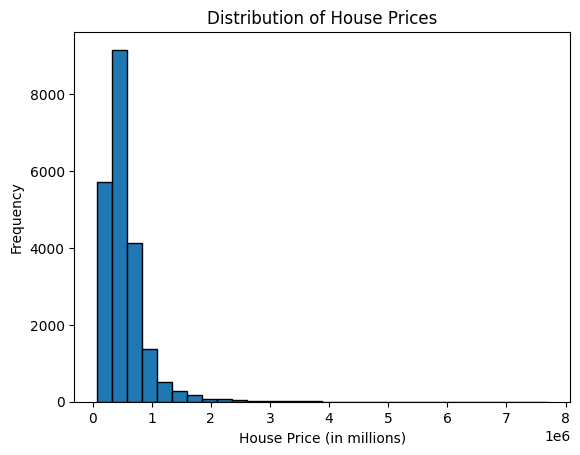

In [133]:
plt.hist(df["price"], bins=30, edgecolor="k")
plt.xlabel("House Price (in millions)")
plt.ylabel("Frequency")
plt.title("Distribution of House Prices")
plt.show()


We visualize the distribution of house prices to check if the data is skewed, normally distributed, or has extreme values.


### 2.3. Correlations (Numerical Features Only)

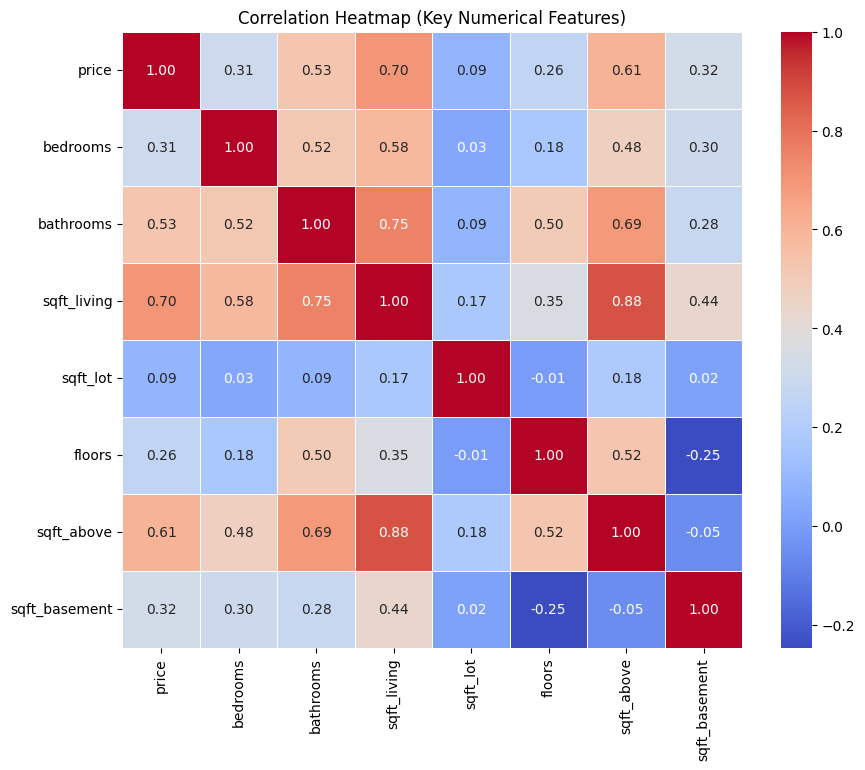

In [134]:
numeric_cols = [
    "price", 
    "bedrooms", 
    "bathrooms", 
    "sqft_living", 
    "sqft_lot", 
    "floors", 
    "sqft_above", 
    "sqft_basement", 
]

# Calculate the correlation matrix
corr = df[numeric_cols].corr()

plt.figure(figsize=(10, 8))

sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f", linewidths=.5)
plt.title("Correlation Heatmap (Key Numerical Features)")
plt.show()

### 2.4 EDA: Feature Relationship (Price vs. Area) 

 

We check the relationship between the key numerical feature (area_sqft) and the target price using a scatter plot. This confirms the strong correlation between house size and value.

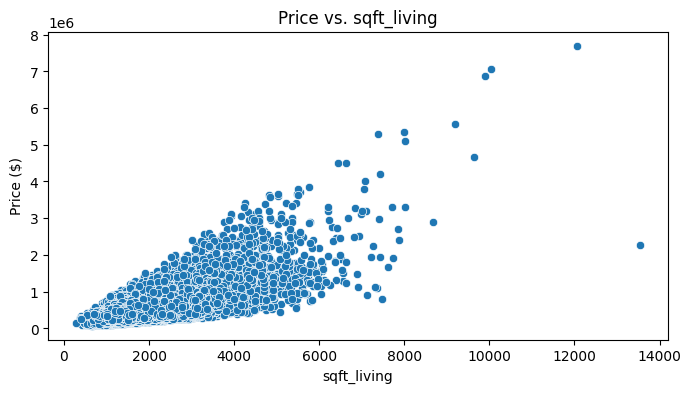

In [135]:
living_area_col = 'sqft_living'

plt.figure(figsize=(8, 4))
sns.scatterplot(x=living_area_col, y='price', data=df)
plt.title(f'Price vs. {living_area_col}')
plt.xlabel(f'{living_area_col}')
plt.ylabel('Price ($)')
plt.show()

### 2.5. Geographic Gradient (Price vs. Latitude) 

We visualize the relationship between latitude and the target price. This demonstrates the existence of a strong geographical value gradient, justifying our use of coordinates and zipcode for segmentation.

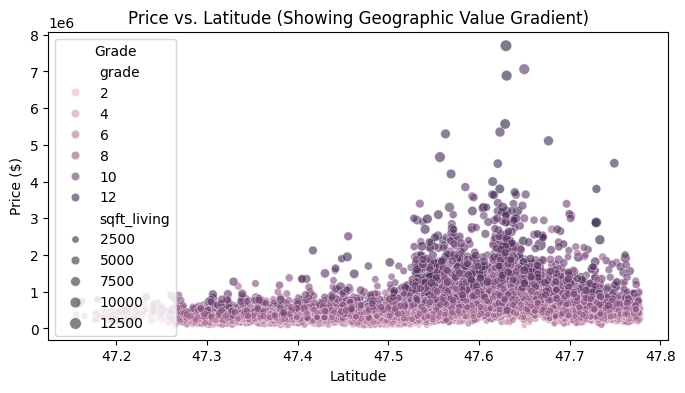

In [136]:
plt.figure(figsize=(8, 4))
sns.scatterplot(x='lat', y='price', data=df, hue='grade', size='sqft_living', alpha=0.6)
plt.title('Price vs. Latitude (Showing Geographic Value Gradient)')
plt.xlabel('Latitude')
plt.ylabel('Price ($)')
plt.legend(title='Grade')
plt.show()

### 2.6. Market Segmentation (Price vs. Zipcode) 

We use a box plot to visualize how the zipcode segments the market. This is the clearest justification for treating zipcode as a crucial categorical feature in our Stacked Ensemble model.

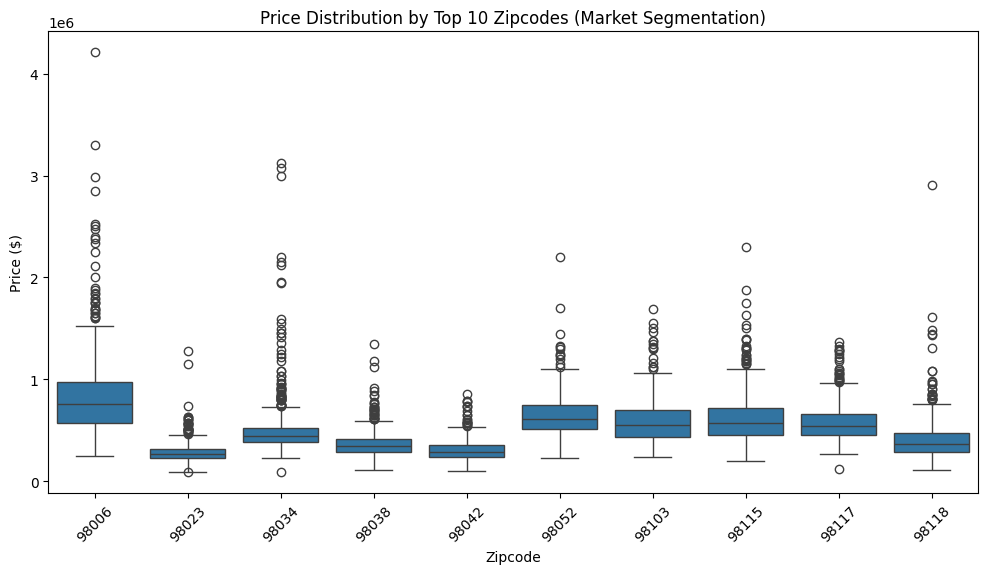

In [137]:
# We select a few top zips for visualization clarity.
top_zips = df['zipcode'].value_counts().head(10).index
df_top_zips = df[df['zipcode'].isin(top_zips)]

plt.figure(figsize=(12, 6))
sns.boxplot(x='zipcode', y='price', data=df_top_zips)
plt.title('Price Distribution by Top 10 Zipcodes (Market Segmentation)')
plt.xlabel('Zipcode')
plt.ylabel('Price ($)')
plt.xticks(rotation=45)
plt.show()

## 3. Data Cleaning and Feature Engineering

We checked the data and there are no missing values and everything sseems to be clean. We are not going to remove the outliers, because the model that we are using is not affected by those. We can safely jump to feature engineering now.

### 3.1 Data Splitting (Train/Test) 

We separate our data into training and testing sets. This is a critical step to ensure our model's performance evaluation is reliable.

In [138]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Training set size: {X_train.shape[0]}, Test set size: {X_test.shape[0]}")

Training set size: 17290, Test set size: 4323


### 3.2 Feature Categorization and Binary Encoding 

We define our feature types and manually convert all yes/no binary features to 1/0. This simple encoding promotes model transparency.

In [ ]:
# --- DEFINING FEATURE SETS ---
numerical_features = [
    'sqft_living', 'sqft_lot', 'floors', 'sqft_above', 'sqft_basement', 
    'yr_built', 'yr_renovated', 'lat', 'long', 'bedrooms', 'bathrooms'
]

# Features treated as categories 
categorical_features = ['waterfront', 'view', 'condition', 'grade', 'zipcode'] 

# 1. Age of House (Time Feature)
# Calculate the effective age of the house (0 if renovated, otherwise based on built year)
current_year = 2025
X_train['house_age'] = current_year - X_train['yr_built']
X_test['house_age'] = current_year - X_test['yr_built']

# 2. Density Feature (Living Area per Room)
X_train['sqft_per_room'] = X_train['sqft_living'] / X_train['bedrooms'].replace(0, 1)
X_test['sqft_per_room'] = X_test['sqft_living'] / X_test['bedrooms'].replace(0, 1)

# 3. Renovation Status (Binary Feature)
# A simple binary flag showing if the house was ever renovated
X_train['is_renovated'] = X_train['yr_renovated'].apply(lambda x: 1 if x > 0 else 0)
X_test['is_renovated'] = X_test['yr_renovated'].apply(lambda x: 1 if x > 0 else 0)


# Update feature lists
numerical_features.extend(['house_age', 'sqft_per_room'])
categorical_features.append('is_renovated') 

print("New time-based, density, and binary features engineered.")

New time-based, density, and binary features engineered.


### 3.3 Defining the Preprocessing Pipeline 

We define the ColumnTransformer. Numerical features are Scaled for fair weighting in the Linear Regression, and the multi-class feature is One-Hot Encoded.

In [ ]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', Pipeline([
            ('imputer', SimpleImputer(strategy='median')), 
            ('scaler', StandardScaler())
        ]), numerical_features),
        
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_features)
    ],
    remainder='drop'
)
print("Preprocessing ColumnTransformer defined, treating zipcode as a categorical feature for segmentation.")

Preprocessing ColumnTransformer defined, treating zipcode as a categorical feature for segmentation.


## 4. Model Training (Model 1: Price Valuation)

### 4.1 Model 1: Defining the Stacked Ensemble Pipeline 

We define the Stacked Ensemble using diverse base models (XGBoost, LightGBM, Ridge) to maximize accuracy.

In [ ]:
# Define the base models (Level 0)
base_models = [
    ('xgb', XGBRegressor(n_estimators=200, learning_rate=0.05, random_state=42)), # Higher n_estimators for better accuracy
    ('lgbm', LGBMRegressor(n_estimators=200, learning_rate=0.05, random_state=42)),
    ('ridge', Ridge(alpha=1.0)) 
]

# Define the Stacking Regressor (Level 1 Meta-Learner is Ridge)
stacked_model = StackingRegressor(
    estimators=base_models,
    final_estimator=Ridge(alpha=10),
    cv=5 
)

# Chain the preprocessor with the Stacked Model
final_model_stack = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', stacked_model)
])
print("Final Model Pipeline defined: Preprocessing -> Stacked Ensemble Regressor.")

Final Model Pipeline defined: Preprocessing -> Stacked Ensemble Regressor.


### 4.2 Training Model 1 and Evaluation 

We train the Stacked Ensemble and calculate a robust set of KPIs.

In [ ]:
print("Training Stacked Ensemble Model (Model 1) for Maximum Accuracy...")
final_model_stack.fit(X_train, y_train)
print("Model 1 Training Complete.")

y_pred = final_model_stack.predict(X_test)

# Definign the  KPIs
test_r2 = r2_score(y_test, y_pred)
test_mae = mean_absolute_error(y_test, y_pred)
test_mse = mean_squared_error(y_test, y_pred)
test_rmse = np.sqrt(test_mse)
test_mape = mean_absolute_percentage_error(y_test, y_pred) 

print("\n--- Model 1 Evaluation (Comprehensive KPIs) ---")
print(f"Test R² Score (Reliability): {test_r2:.4f}")
print(f"Test MAE (Avg. Price Error): ${test_mae:,.2f}")
print(f"Test RMSE (Std. Dev. of Error): ${test_rmse:,.2f}")
print(f"Test MAPE (Percentage Error): {test_mape:.2%}")

Training Stacked Ensemble Model (Model 1) for Maximum Accuracy...
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001351 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2289
[LightGBM] [Info] Number of data points in the train set: 17290, number of used features: 106
[LightGBM] [Info] Start training from score 537768.591614
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.003802 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2249
[LightGBM] [Info] Number of data points in the train set: 13832, number of used features: 106
[LightGBM] [Info] Start training from score 536800.890471
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001956 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memor

### 4.3 Model Transparency: Extracting Feature Weights 

We extract and display the Feature Importance scores from the Stacked Ensemble model. This provides clear, non-monetary justification for the prediction, fulfilling our transparency requirement.

In [ ]:
feature_names_out = (
    numerical_features + 
    list(preprocessor.named_transformers_['cat'].get_feature_names_out(categorical_features))
)

# 1. Access the trained LightGBM model
trained_stack = final_model_stack['regressor'].estimators_
lgbm_model = trained_stack[1] 


# 2. Extract feature importance from LightGBM
importance = lgbm_model.feature_importances_

importance_df_lgbm = pd.DataFrame({'Feature': feature_names_out, 'Importance Score': importance})
importance_df_lgbm = importance_df_lgbm.sort_values(by='Importance Score', ascending=False)

print("--- Feature Importance (Based on LightGBM Component) ---")
print(importance_df_lgbm.head(10))

--- Explicit Feature Importance (Based on LightGBM Component) ---
          Feature  Importance Score
7             lat               822
8            long               678
0     sqft_living               614
1        sqft_lot               445
5        yr_built               441
3      sqft_above               435
4   sqft_basement               319
12  sqft_per_room               250
10      bathrooms               219
15         view_0               104


## 4.4. Saving the model(for a later use)

In [151]:
model_to_save = final_model_stack
filename = 'stacked_ensemble_model_1.joblib'

joblib.dump(model_to_save, filename)

print(f"\nModel 1 (final_model_stack) successfully saved as: {filename}")


Model 1 (final_model_stack) successfully saved as: stacked_ensemble_model_1.joblib


## 5. Deployment and Decision Support (Model 2: Affordability)

### 5.1 Model 2: Defining Lending Constants and Functions 

We define the traditional bank lending metrics (max HER/DTI ratios) and the essential mathematical functions needed to calculate monthly mortgage payments.

In [ ]:
# --- Model 2 Constants (Traditional Lending Outlook) ---
MAX_HER_RATIO = 0.28  # Max Housing Expense Ratio (28%)
MAX_DTI_RATIO = 0.36  # Max Debt-to-Income Ratio (36%)
MORTGAGE_RATE = 0.05  # Example Annual Interest Rate
YEARS = 25            # Example Loan Term in years

# --- Mathematical Formula for Monthly Mortgage Payment (P&I) ---
def calculate_monthly_payment(principal, annual_rate, years):
    r = annual_rate / 12       
    n = years * 12             
    if r == 0:
        return principal / n
    return principal * (r * (1 + r)**n) / ((1 + r)**n - 1)

### 5.2 Model 2: Affordability Decision Logic (Rule-Based Classifier) 

This is the core logic of Model 2. It classifies the loan risk (Approve, Flag, Deny) based on the predicted house price and borrower's micro-financial data (HER/DTI).

In [ ]:
MIN_CREDIT_SCORE = 680 # Traditional minimum score for a prime mortgage

def affordability_decision_model(predicted_price, user_data):
    """Provides a non-final decision suggestion based on enhanced DTI/HER rules using Total Household Income."""
    
    # Calculate Total Household Income
    total_yearly_income = user_data['yearly_income'] + user_data.get('co_borrower_yearly_income', 0)
    monthly_income = total_yearly_income / 12
    
    down_payment_ratio = user_data.get('down_payment_ratio', 0.20)
    down_payment = user_data['savings_total'] * down_payment_ratio 
    loan_principal = predicted_price - down_payment
    
   
    if user_data['credit_score'] < MIN_CREDIT_SCORE:
        return "DENY: Credit Score Below Minimum (Required: 680)", 0, 0
    
    # Net Worth consideration (Higher net worth provides higher stability)
    net_worth_factor = 1.0 
    if user_data['net_worth'] > loan_principal * 0.5:
        net_worth_factor = 0.9 # 10% more leniency on DTI for high-net-worth clients
    
    # Safety Check 1: Insufficient Down Payment
    if down_payment < (predicted_price * 0.05):
        return "DENY: Insufficient Down Payment", 0, 0
    
    est_mortgage_payment = calculate_monthly_payment(loan_principal, MORTGAGE_RATE, YEARS)
    
    # Calculate Key Bank Ratios
    her = est_mortgage_payment / monthly_income
    total_monthly_debt = user_data['other_monthly_loans'] + est_mortgage_payment
    dti = total_monthly_debt / monthly_income
    
    # Adjusted DTI Threshold based on stability factors
    adjusted_max_dti = MAX_DTI_RATIO * net_worth_factor
    
    # Reward for excellent credit history 
    if user_data['credit_score'] >= 760:
        adjusted_max_dti *= 1.05 # 5% more leniency
    
    # Safety Check 2: Family Burden (Higher scrutiny for large families)
    family_members = user_data['family_members']
    if family_members >= 5 and dti > adjusted_max_dti * 0.9: 
        return "FLAG FOR REVIEW: High Debt & Large Household Burden", her, dti

    # Decision Matrix (Rule-Based Classification)
    decision = "APPROVE: Low Risk - Meets Standards"
    if her > MAX_HER_RATIO:
        decision = "DENY: Housing Payment Exceeds Max 28% HER"
    elif dti > adjusted_max_dti:
        decision = "FLAG FOR REVIEW: High Overall Debt (DTI > 36%)" 
        
    return decision, her, dti

### 5.3 Full System Demonstration: Data Entry and Output 

We simulate the Human-in-the-Loop workflow. The bank employee enters the applicant's data, and the system executes Models 1 and 2 to generate the final loan risk suggestion.

In [ ]:
# --- 1. Bank Employee Data Entry (Loan Applicant's Micro-Financial Data) ---
user_micro_data = {
    'yearly_income': 180000,             
    'co_borrower_yearly_income': 60000, # NEW: Co-Borrower's Income (Total Household Income)
    'other_monthly_loans': 900,          
    'savings_total': 250000,             
    'down_payment_ratio': 0.20,
    'net_worth': 850000,           
    'family_members': 4,              
    'credit_score': 780              
}

# --- 2. Bank Employee Property Data Entry (Subject Property's Features) ---
property_input_for_demo = pd.DataFrame({
    'date': ['20150212T000000'], 'bedrooms': [4], 'bathrooms': [2.5], 'sqft_living': [2500], 
    'sqft_lot': [7500], 'floors': [2.0], 'waterfront': [0], 'view': [2], 'condition': [3], 
    'grade': [7], 'sqft_above': [1800], 'sqft_basement': [700], 'yr_built': [1985], 
    'yr_renovated': [0], 'zipcode': [98001], 'lat': [47.5], 'long': [-122.2]
})

# Feature Creation and Prediction 
current_year = 2025
property_input_for_demo['house_age'] = current_year - property_input_for_demo['yr_built']
property_input_for_demo['sqft_per_room'] = property_input_for_demo['sqft_living'] / property_input_for_demo['bedrooms'].replace(0, 1)
property_input_for_demo['is_renovated'] = property_input_for_demo['yr_renovated'].apply(lambda x: 1 if x > 0 else 0)

print("--- EstateMate Loan Decision Support System ---")

# Step 3: Predict House Price (Model 1)
predicted_price = final_model_stack.predict(property_input_for_demo)[0]
print(f"1. Model 1 (Valuation): Predicted House Price = ${predicted_price:,.0f}")

# Step 4: Affordability Decision (Model 2)
decision, her, dti = affordability_decision_model(predicted_price, user_micro_data)

print("\n2. Model 2 (Affordability) Metrics:")
print(f"   * Total Household Income: ${user_micro_data['yearly_income'] + user_micro_data['co_borrower_yearly_income']:,.0f}")
print(f"   * Credit Score: {user_micro_data['credit_score']}")
print(f"   * Net Worth: ${user_micro_data['net_worth']:,.0f}")
print(f"   * HER (Housing Expense Ratio): {her:.2%} (Target Max: {MAX_HER_RATIO:.0%})")
print(f"   * DTI (Debt-to-Income Ratio): {dti:.2%} (Target Max: {MAX_DTI_RATIO:.0%})")

print("\n3. EstateMate Final Suggestion (Human-in-the-Loop):")
print(f"   **{decision}**")

--- EstateMate Loan Decision Support System ---
1. Model 1 (Valuation): Predicted House Price = $409,177

2. Model 2 (Affordability) Metrics:
   * Total Household Income: $240,000
   * Credit Score: 780
   * Net Worth: $850,000
   * HER (Housing Expense Ratio): 14.00% (Target Max: 28%)
   * DTI (Debt-to-Income Ratio): 20.00% (Target Max: 36%)

3. EstateMate Final Suggestion (Human-in-the-Loop):
   **APPROVE: Low Risk - Meets Standards**


## 5.4. Saving the model

This model  is not a traditional one, but it is a function from the first mode, therefore we have to save this one with some constants and we cannot use the joblib libreary, but instead the pickle module.

In [ ]:
model_2_components = {
    'affordability_function': affordability_decision_model,
    'MAX_HER_RATIO': MAX_HER_RATIO,
    'MAX_DTI_RATIO': MAX_DTI_RATIO,
    'MORTGAGE_RATE': MORTGAGE_RATE,
    'YEARS': YEARS,
    'MIN_CREDIT_SCORE': MIN_CREDIT_SCORE
}

filename = 'model_2_affordability_rules.pkl'

# 2. Save the components to disk using pickle
with open(filename, 'wb') as file:
    pickle.dump(model_2_components, file)

print(f"\nModel 2 (Affordability Logic) successfully saved as: {filename}")


Model 2 (Affordability Logic) successfully saved as: model_2_affordability_rules.pkl
